In [6]:
#libraries 
#Dataframe and serries manipulation 
import pandas as pd
#Tokenization 
import nltk 
from nltk.tokenize import sent_tokenize, word_tokenize
#stopwords
from nltk.corpus import stopwords
#Vector space model 
from sklearn.feature_extraction.text import TfidfVectorizer 
#Indonesian converter 
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
#math function 
import math 
#plot 
import matplotlib.pyplot as plt 


In [3]:
#Define document
sentence = """
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

In [24]:
#Text preprocessing 
#Extract to each sentences
sent_token = sent_tokenize(sentence)
print(type(sent_token))


<class 'list'>


In [17]:
#Remove stopwords
import string
nltk.download('punkt')
nltk.download('stopwords')
#Initializing
stop_words = set(stopwords.words('english'))
sentence = """
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""
tokens = word_tokenize(sentence.lower())

# Remove stopwords 
filtered_tokens = [word for word in tokens 
                   if word not in stop_words and word not in string.punctuation]

print("original:", tokens)
print("filtered:", filtered_tokens)


original: ['manchester', 'city', 'makes', 'history', 'by', 'winning', 'club', 'world', 'cup', 'manchester', 'city', 'capped', 'off', 'its', 'incredible', 'year', 'with', 'yet', 'another', 'trophy', ',', 'dismantling', 'fluminense', '4-0', 'to', 'win', 'the', 'club', 'world', 'cup', 'on', 'friday', '.', 'having', 'already', 'won', 'the', 'premier', 'league', ',', 'champions', 'league', ',', 'fa', 'cup', 'and', 'super', 'cup', ',', 'pep', 'guardiola', '’', 's', 'side', 'now', 'boasts', 'five', 'trophies', 'this', 'calendar', 'year', ',', 'becoming', 'the', 'first', 'english', 'club', 'to', 'ever', 'hold', 'all', 'those', 'titles', 'simultaneously', '.', 'the', 'final', 'piece', 'of', 'the', 'jigsaw', 'came', 'on', 'a', 'highly', 'charged', 'night', 'in', 'saudi', 'arabia', 'as', 'manchester', 'city', 'outclassed', 'its', 'brazilian', 'opponents', '.', '“', 'we', '’', 've', 'shown', 'over', 'the', 'past', '12', 'months', 'we', 'are', 'the', 'best', 'team', 'in', 'the', 'world', '.', 'our'

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
clean_sentence = " ".join(filtered_tokens)

sent_token = sent_tokenize(clean_sentence)
print(sent_token)

['manchester city makes history winning club world cup manchester city capped incredible year yet another trophy dismantling fluminense 4-0 win club world cup friday already premier league champions league fa cup super cup pep guardiola ’ side boasts five trophies calendar year becoming first english club ever hold titles simultaneously final piece jigsaw came highly charged night saudi arabia manchester city outclassed brazilian opponents “ ’ shown past 12 months best team world results prove consistency managed amazing ” club captain kyle walker said game per sky sports “ win five trophies – five biggest prizes available us – incredible proud part honestly say ’ honour play alongside players ’ ask better teammates.', '” took 40 seconds manchester city take lead brazilian left-back marcelo miscued pass opening exchanges let nathan aké free shoot distance defender ’ effort cannoned back post forward julián álvarez right place turn rebound net chest city continued look dangerous doubled

In [26]:
#training TF-IDF on filtered sentence
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(sent_token)
print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)

print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after  stop word removal):")
print(features.shape)



TF-IDF Feature Matrix (Sparse) on cleaned sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 232 stored elements and shape (3, 198)>
  Coords	Values
  (0, 104)	0.2051305155778907
  (0, 36)	0.15930214450164454
  (0, 101)	0.08990732560670416
  (0, 84)	0.08990732560670416
  (0, 193)	0.08990732560670416
  (0, 39)	0.27350735410385424
  (0, 194)	0.26972197682011245
  (0, 45)	0.3596293024268166
  (0, 30)	0.06837683852596356
  (0, 89)	0.13675367705192712
  (0, 195)	0.13675367705192712
  (0, 196)	0.06837683852596356
  (0, 11)	0.06837683852596356
  (0, 179)	0.08990732560670416
  (0, 51)	0.08990732560670416
  (0, 73)	0.06837683852596356
  (0, 192)	0.13675367705192712
  (0, 78)	0.08990732560670416
  (0, 8)	0.08990732560670416
  (0, 135)	0.06837683852596356
  (0, 95)	0.13675367705192712
  (0, 33)	0.08990732560670416
  (0, 62)	0.08990732560670416
  (0, 166)	0.08990732560670416
  (0, 125)	0.08990732560670416
  :	:
  (2, 48)	0.13764607304339951
  (2, 115)	0.13764607304339951
  (

In [27]:
#to see the feature names 
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names ")
print(feature_names)


Feature Names (Words in the vocabulary after Indonesian stop word removal):
['12' '40' '72nd' '88th' 'according' 'achieved' 'aké' 'alongside'
 'already' 'always' 'amazing' 'another' 'arabia' 'ask' 'attempted'
 'available' 'back' 'becoming' 'best' 'better' 'biggest' 'boasts' 'boss'
 'brazilian' 'break' 'brilliant' 'broke' 'calendar' 'came' 'cannoned'
 'capped' 'captain' 'champion' 'champions' 'charged' 'chest' 'city'
 'clinical' 'close' 'club' 'completed' 'consistency' 'continued' 'corner'
 'cross' 'cup' 'currently' 'dangerous' 'defence' 'defender' 'deflected'
 'dismantling' 'distance' 'dominance' 'doubled' 'effort' 'ended' 'england'
 'english' 'ever' 'everton' 'exchanges' 'fa' 'face' 'faces' 'fans' 'far'
 'fight' 'final' 'finish' 'first' 'five' 'fixture' 'fluminense' 'foden'
 'forward' 'fourth' 'free' 'friday' 'game' 'got' 'guardiola' 'heads'
 'highly' 'history' 'hold' 'home' 'honestly' 'honour' 'incredible'
 'jigsaw' 'julián' 'kyle' 'largely' 'lead' 'league' 'left' 'let' 'lift'
 'loo

In [36]:
if filtered_tokens:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd 
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence"""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] >0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")


TF-IDF values for the first cleaned sentence:
[[0.08990733 0.         0.         0.         0.         0.
  0.         0.08990733 0.08990733 0.         0.08990733 0.06837684
  0.08990733 0.08990733 0.         0.08990733 0.         0.08990733
  0.08990733 0.08990733 0.08990733 0.08990733 0.         0.06837684
  0.         0.         0.         0.08990733 0.08990733 0.
  0.06837684 0.08990733 0.         0.08990733 0.08990733 0.
  0.15930214 0.         0.         0.27350735 0.         0.08990733
  0.         0.         0.         0.3596293  0.         0.
  0.         0.         0.         0.08990733 0.         0.
  0.         0.         0.         0.         0.06837684 0.06837684
  0.         0.         0.08990733 0.         0.         0.
  0.         0.         0.06837684 0.         0.08990733 0.20513052
  0.         0.06837684 0.         0.         0.         0.
  0.08990733 0.05310071 0.         0.06837684 0.         0.08990733
  0.08990733 0.06837684 0.         0.08990733 0.08990733 

**List of Sentences:**
1. manchester city makes history winning club world cup manchester city capped incredible year yet another trophy dismantling fluminense 4-0 win club world cup friday already premier league champions league fa cup super cup pep guardiola ’ side boasts five trophies calendar year becoming first english club ever hold titles simultaneously final piece jigsaw came highly charged night saudi arabia manchester city outclassed brazilian opponents “ ’ shown past 12 months best team world results prove consistency managed amazing ” club captain kyle walker said game per sky sports “ win five trophies – five biggest prizes available us – incredible proud part honestly say ’ honour play alongside players ’ ask better teammates.
2. ” took 40 seconds manchester city take lead brazilian left-back marcelo miscued pass opening exchanges let nathan aké free shoot distance defender ’ effort cannoned back post forward julián álvarez right place turn rebound net chest city continue

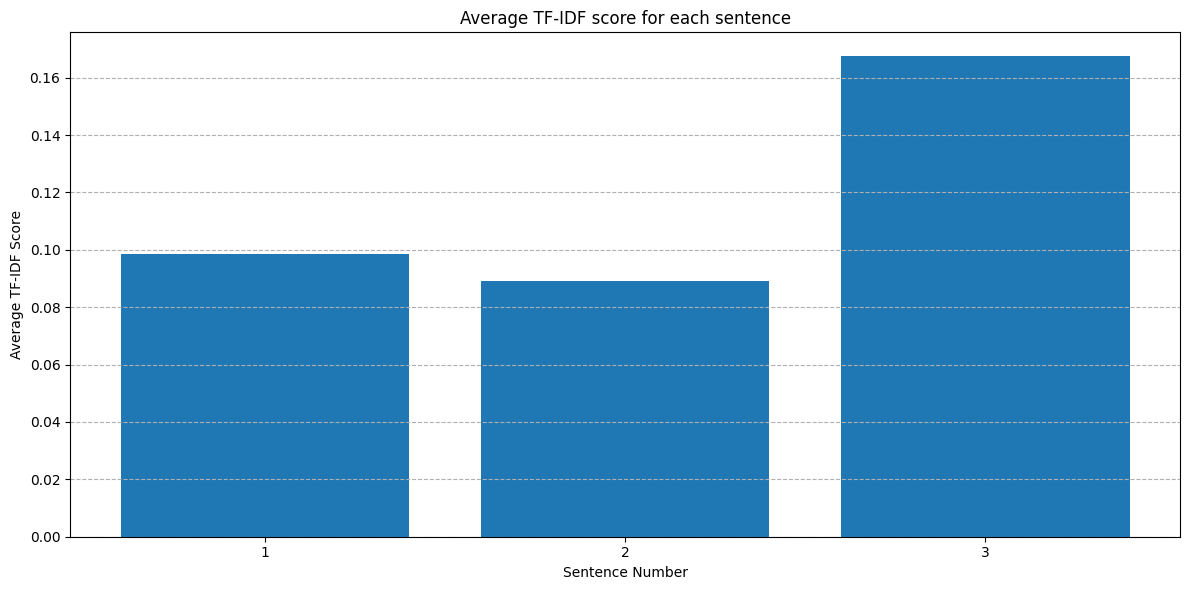

In [38]:
#calculate sentence score 
sent_index = 0 
sent_scores = []

#calculate sentence TF-IDF score and list sentence 
print("**List of Sentences:**")
for i, sent in enumerate(sent_token):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

#calculate average TF-IDF score for each setence 
for i in features:
    print(f"- Sentence{sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print("sum of TF-IDF scores:", sent_score)
    print("Number of words:", sent_length)
    avg_score = sent_score/sent_length if sent_length > 0 else 0 
    print("Average TF-IDF score:", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1
print("\n----------------------------")
print("\nList of average TF-IDF scores for each sentence:")
print(sent_scores)

#visualize the average TF-IDF scores as a historgram 
plt.figure(figsize=(12,6))
plt.bar(range(1, len(sent_scores)+1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF score for each sentence")
plt.xticks(range(1,len(sent_scores)+1))
plt.grid(axis='y',linestyle='--')
plt.tight_layout()
plt.show()

In [59]:
#Define Threshold 
sentence = """
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""
sent_token2 = sent_tokenize(sentence)
# print(sent_token2)
#word token 
tokens = word_tokenize(sentence)
print(tokens)
stop_words = set(stopwords.words('english'))

# #remove stopwords 
filtered_sentence = [word for word in tokens if word not in stop_words and word is not string.punctuation]
print("original :", tokens)
print("filtered_sentence :", filtered_sentence)

#training tf-idf on cleaned sentence 
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(filtered_sentence)

#varaible initilization 
sent_index = 0 
sent_scores = []

# Calculate average TF-IDF score for each sentence
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)





_IncompleteInputError: incomplete input (462631920.py, line 73)

In [63]:
#turn tokenize horizontally into data frame 
df = pd.DataFrame(filtered_sentence, columns=['With_Stopword'])
df.head()

,With_Stopword
0,Manchester
1,City
2,makes
3,history
4,winning


In [61]:
# Final summary initialization 
final_summ = ""

# Get summary sentences
print("\n**Summary Sentences (above or equal to the threshold):**")
for index, data in enumerate( sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + filtered_sentence[index]
        print(f"- {filtered_sentence[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())


**Summary Sentences (above or equal to the threshold):**
- Manchester
- City
- makes
- history
- winning
- Club
- World
- Cup
- Manchester
- City
- capped
- incredible
- year
- yet
- another
- trophy
- dismantling
- Fluminense
- win
- Club
- World
- Cup
- Friday
- Having
- already
- Premier
- League
- Champions
- League
- FA
- Cup
- Super
- Cup
- Pep
- Guardiola
- side
- boasts
- five
- trophies
- calendar
- year
- becoming
- first
- English
- club
- ever
- hold
- titles
- simultaneously
- The
- final
- piece
- jigsaw
- came
- highly
- charged
- night
- Saudi
- Arabia
- Manchester
- City
- outclassed
- Brazilian
- opponents
- We
- shown
- past
- 12
- months
- best
- team
- world
- Our
- results
- prove
- consistency
- managed
- amazing
- club
- captain
- Kyle
- Walker
- said
- game
- per
- Sky
- Sports
- To
- win
- five
- trophies
- five
- biggest
- prizes
- available
- us
- incredible
- proud
- part
- honestly
- say
- honour
- play
- alongside
- players
- ask
- better
- teammates.
- 

In [58]:
final_summ

' Manchester City makes history winning Club World Cup Manchester City capped incredible year yet another trophy dismantling Fluminense win Club World Cup Friday Having already Premier League Champions League FA Cup Super Cup Pep Guardiola side boasts five trophies calendar year becoming first English club ever hold titles simultaneously The final piece jigsaw came highly charged night Saudi Arabia Manchester City outclassed Brazilian opponents We shown past 12 months best team world Our results prove consistency managed amazing club captain Kyle Walker said game per Sky Sports To win five trophies five biggest prizes available us incredible proud part honestly say honour play alongside players ask better teammates. It took 40 seconds Manchester City take lead Brazilian Marcelo miscued pass opening exchanges let Nathan Aké free shoot distance The defender effort cannoned back post forward Julián Álvarez right place turn rebound net chest City continued look dangerous doubled lead break